# Day 10: SGLang — RadixAttention & Structured Outputs
> *100 Days of Inference* | Layer: **Runtime** | Book: *Inference Engineering* Ch 4.3.2 (pp. 108–109)

**Prerequisite:** Day 09 (vLLM / PagedAttention)

**Goal:** Understand SGLang's core innovations: RadixAttention for automatic KV cache reuse across requests, and structured output generation.

## What problem does this solve?

vLLM's PagedAttention manages memory well, but it still recomputes the KV cache from scratch for every new request — even if that request starts with the exact same 1000-token system prompt as the previous 10,000 requests.

Also: when a model needs to produce structured output (JSON, XML, code), the naive approach generates tokens freely and then validates/retries. This is wasteful and unreliable.

SGLang's answer: RadixAttention — an automatic prefix caching system that works like a trie/radix tree to maximize KV cache reuse across *all* incoming requests. And an integrated structured output engine that constrains token generation to valid outputs from the start.

## Concept Overview

**SGLang** (Structured Generation Language) is the second most popular open inference engine after vLLM. SGLang has strong day-zero support for Chinese open models like DeepSeek and Qwen and is the inference engine of choice at xAI.

### RadixAttention
A **radix tree** (also called a prefix tree or trie) stores strings by their shared prefixes. SGLang uses this data structure to store KV cache blocks: if two requests share a common prefix, they reuse the same physical KV cache blocks.

**Infrastructure analogy:** This is like a shared filesystem with deduplication. Two Docker containers based on the same base image share the base image layers on disk — they don't each get their own copy. RadixAttention does the same for KV cache: shared prefix = shared memory.

### Structured Outputs
Instead of generating freely and validating after, SGLang constrains the token logits to only allow tokens that are valid continuations of the structured format (JSON schema, regex, etc.). This is called **constrained decoding** — it's like a type system for model output.

In [1]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import torch
import hashlib
from typing import Dict, List, Optional, Tuple
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10
GPU Memory: 128.5 GB


## Part 1: Prefix Trees (Radix Trees) — The Data Structure

A **trie** (or radix tree) stores sequences by their shared prefixes. Each node represents a common prefix shared by multiple entries.

For token sequences:
- Request A: `[system_prompt] + ["What is Python?"]`
- Request B: `[system_prompt] + ["Explain Docker"]`
- Request C: `[system_prompt] + ["What is Kubernetes?"]`

All three share `[system_prompt]`. The radix tree stores those tokens' KV cache once. A, B, C each get their own unique suffix.

The savings scale with: (shared_prefix_length / total_sequence_length) × (prefill_compute_cost).

In [2]:
# Implement a simple radix tree / prefix trie for token sequences

class RadixNode:
    def __init__(self):
        self.children: Dict[int, 'RadixNode'] = {}  # token_id -> child node
        self.kv_cache_block: Optional[int] = None   # physical block ID if cached
        self.ref_count: int = 0                      # active requests using this node

class RadixTree:
    """Simplified RadixAttention tree for prefix KV cache sharing."""
    def __init__(self, block_size=16):
        self.root = RadixNode()
        self.block_size = block_size
        self.next_block_id = 0
        self.cache_hits = 0
        self.cache_misses = 0

    def _allocate_block(self):
        bid = self.next_block_id
        self.next_block_id += 1
        return bid

    def match_prefix(self, token_ids: List[int]) -> Tuple[int, List[int]]:
        """
        Returns: (num_cached_tokens, remaining_tokens)
        num_cached_tokens: how many tokens from the start are already in cache
        """
        node = self.root
        cached = 0
        for i, token in enumerate(token_ids):
            if token in node.children:
                child = node.children[token]
                if child.kv_cache_block is not None:
                    cached = i + 1
                    self.cache_hits += 1
                node = child
            else:
                self.cache_misses += 1
                break
        return cached, token_ids[cached:]

    def insert(self, token_ids: List[int]):
        """Insert token sequence into the tree, allocating blocks."""
        node = self.root
        for token in token_ids:
            if token not in node.children:
                child = RadixNode()
                child.kv_cache_block = self._allocate_block()
                node.children[token] = child
            node = node.children[token]
        node.ref_count += 1

    def tree_size(self):
        """Count total nodes in tree."""
        def count(node):
            return 1 + sum(count(c) for c in node.children.values())
        return count(self.root) - 1  # exclude root

# Simulate requests with shared system prompt
SYSTEM_PROMPT = list(range(100))  # 100 tokens system prompt
USER_QUESTIONS = [
    list(range(1000, 1015)),  # 15-token question
    list(range(2000, 2012)),  # 12-token question
    list(range(3000, 3020)),  # 20-token question
    list(range(1000, 1015)),  # Same as first! Perfect cache hit
    list(range(4000, 4008)),  # 8-token question
]

tree = RadixTree(block_size=16)

print("RadixAttention prefix cache simulation")
print(f"System prompt: {len(SYSTEM_PROMPT)} tokens")
print()
print(f"{'Request':>8} {'Total tokens':>13} {'Cached':>8} {'To compute':>12} {'Cache hit%':>11}")
print("-" * 60)

total_tokens = 0
total_cached = 0

for i, question in enumerate(USER_QUESTIONS):
    full_seq = SYSTEM_PROMPT + question
    cached, remaining = tree.match_prefix(full_seq)
    tree.insert(full_seq)

    total_tokens += len(full_seq)
    total_cached += cached
    hit_rate = cached / len(full_seq) * 100
    print(f"{i+1:>8} {len(full_seq):>13} {cached:>8} {len(remaining):>12} {hit_rate:>10.1f}%")

print("-" * 60)
overall_rate = total_cached / total_tokens * 100
print(f"{'Overall':>8} {total_tokens:>13} {total_cached:>8} {total_tokens-total_cached:>12} {overall_rate:>10.1f}%")
print()
print(f"Blocks in tree: {tree.next_block_id}")
print(f"Without prefix sharing: {total_tokens} tokens would need KV cache")
print(f"With RadixAttention: only {total_tokens - total_cached} tokens computed")

RadixAttention prefix cache simulation
System prompt: 100 tokens

 Request  Total tokens   Cached   To compute  Cache hit%
------------------------------------------------------------
       1           115        0          115        0.0%
       2           112      100           12       89.3%
       3           120      100           20       83.3%
       4           115      115            0      100.0%
       5           108      100            8       92.6%
------------------------------------------------------------
 Overall           570      415          155       72.8%

Blocks in tree: 155
Without prefix sharing: 570 tokens would need KV cache
With RadixAttention: only 155 tokens computed


## Part 2: Cache Hit Rate vs Workload Pattern

The benefit of RadixAttention depends entirely on how much prefix sharing the workload has:

- **Chatbot with long system prompt:** High hit rate — all requests share the system prompt
- **Code completion:** High hit rate — users working in the same codebase share file context
- **RAG (Retrieval Augmented Generation):** Medium — some documents are retrieved multiple times
- **One-off diverse queries:** Low hit rate — each request is unique

Cache hit rate by workload type:

  No shared prefix (diverse queries)
    prefix=0, query=200 -> cache hit rate: 0.0%
    Prefill savings: 0.0% fewer tokens to compute
  Short system prompt (50 tokens)
    prefix=50, query=200 -> cache hit rate: 20.0%
    Prefill savings: 20.0% fewer tokens to compute
  Medium system prompt (200 tokens)
    prefix=200, query=200 -> cache hit rate: 49.8%
    Prefill savings: 49.8% fewer tokens to compute
  Long system prompt (500 tokens)
    prefix=500, query=200 -> cache hit rate: 71.0%
    Prefill savings: 71.0% fewer tokens to compute
  Very long context (2000 tokens)
    prefix=2000, query=100 -> cache hit rate: 94.5%
    Prefill savings: 94.5% fewer tokens to compute
  Code completion (5000 token file)
    prefix=5000, query=50 -> cache hit rate: 98.4%
    Prefill savings: 98.4% fewer tokens to compute


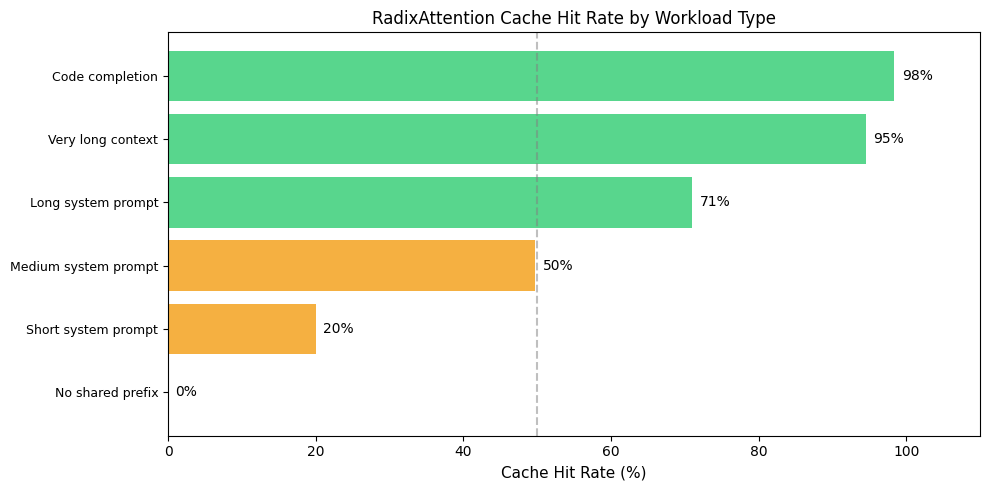

In [3]:
import random
random.seed(42)

def simulate_workload(shared_prefix_len, query_len, n_requests, vocab_size=50000):
    """Simulate requests and measure cache hit rate."""
    ree = RadixTree()
    prefix = list(range(shared_prefix_len))  # Deterministic shared prefix

    total_tokens = 0
    total_cached = 0

    for _ in range(n_requests):
        # Each request: shared prefix + unique query tokens
        query = [random.randint(50000, 50000 + vocab_size) for _ in range(query_len)]
        full_seq = prefix + query
        cached, _ = tree.match_prefix(full_seq)
        tree.insert(full_seq)
        total_tokens += len(full_seq)
        total_cached += cached

    return total_cached / total_tokens if total_tokens > 0 else 0

# Different workload types
workloads = {
    "No shared prefix (diverse queries)": (0, 200, 100),
    "Short system prompt (50 tokens)": (50, 200, 100),
    "Medium system prompt (200 tokens)": (200, 200, 100),
    "Long system prompt (500 tokens)": (500, 200, 100),
    "Very long context (2000 tokens)": (2000, 100, 100),
    "Code completion (5000 token file)": (5000, 50, 100),
}

print("Cache hit rate by workload type:")
print()
names = []
rates = []
for name, (prefix_len, query_len, n_req) in workloads.items():
    hit_rate = simulate_workload(prefix_len, query_len, n_req)
    total_len = prefix_len + query_len
    names.append(name)
    rates.append(hit_rate)
    print(f"  {name}")
    print(f"    prefix={prefix_len}, query={query_len} -> cache hit rate: {hit_rate:.1%}")
    print(f"    Prefill savings: {hit_rate:.1%} fewer tokens to compute")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if r > 0.5 else '#e74c3c' if r < 0.2 else '#f39c12' for r in rates]
bars = ax.barh(range(len(names)), [r * 100 for r in rates], color=colors, alpha=0.8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels([n.split('(')[0].strip() for n in names], fontsize=9)
ax.set_xlabel('Cache Hit Rate (%)', fontsize=11)
ax.set_title('RadixAttention Cache Hit Rate by Workload Type', fontsize=12)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{rate:.0%}', va='center', fontsize=10)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

## Part 3: Structured Output Generation

Structured output constrains the model's token generation to only produce valid tokens for a given schema at each step. This is **constrained decoding**.

The mechanism: before softmax, mask out (set to -inf) any token that would make the output invalid at the current position. Only valid continuations get non-zero probability.

**Infrastructure analogy:** Like input validation but applied *during* generation, not after. Instead of letting the model produce free text and then checking if it's valid JSON, JSON structure is enforced at every token step. The model can only choose tokens that are legal JSON continuations of what's been generated so far.

In [4]:
# Simulate constrained decoding for JSON output
# Simplified state machine for valid JSON structure

import json

class JSONStateMachine:
    """
    Extremely simplified JSON state machine.
    In production (SGLang/outlines), this handles full JSON schema.
    """
    STATES = ['start', 'in_object', 'after_key', 'after_colon', 'after_value', 'end']

    def __init__(self, schema):
        self.state = 'start'
        self.schema = schema  # Expected fields
        self.current_key = None
        self.result = {}

    def valid_next_tokens(self):
        """Return set of valid next tokens given current state."""
        if self.state == 'start':
            return ['{']
        elif self.state == 'in_object':
            remaining_keys = [k for k in self.schema if k not in self.result]
            if not remaining_keys:
                return ['}']
            return [f'"{k}"' for k in remaining_keys] + (['}'] if self.result else [])
        elif self.state == 'after_key':
            return [':']
        elif self.state == 'after_colon':
            # Value depends on schema type
            key_type = self.schema.get(self.current_key, 'string')
            if key_type == 'integer':
                return [str(i) for i in range(100)]
            else:
                return ['"...string value..."']  # simplified
        elif self.state == 'after_value':
            remaining = [k for k in self.schema if k not in self.result]
            return [',' if remaining else '}']  
        return []

schema = {'name': 'string', 'age': 'integer', 'role': 'string'}
sm = JSONStateMachine(schema)

# Simulate constrained generation steps
generation_trace = [
    ('{',             'in_object'),
    ('"name"',        'after_key'),
    (':',             'after_colon'),
    ('"Alice"',       'after_value'),
    (',',             'in_object'),
    ('"age"',         'after_key'),
    (':',             'after_colon'),
    ('30',            'after_value'),
    (',',             'in_object'),
    ('"role"',        'after_key'),
    (':',             'after_colon'),
    ('"engineer"',    'after_value'),
    ('}',             'end'),
]

print("Constrained JSON generation trace:")
print(f"Schema: {schema}")
print()

vocab_size = 50000
output = ""
print(f"{'Step':>4} {'Token generated':>20} {'Next state':>14} {'Valid tokens':>14} {'Blocked tokens':>16}")
print("-" * 75)

state = 'start'
for i, (token, next_state) in enumerate(generation_trace):
    sm.state = state
    valid = sm.valid_next_tokens()
    n_valid = len(valid) if valid else 0
    n_blocked = vocab_size - n_valid  # Tokens masked out
    print(f"{i+1:>4} {token:>20} {next_state:>14} {n_valid:>14} {n_blocked:>16,}")
    output += token
    state = next_state

print()
print(f"Generated output: {output}")
print()
print(f"At most generation steps, {vocab_size - 1:,} out of {vocab_size:,} tokens are blocked.")
print("The model can ONLY generate valid JSON at every step.")
print("No validation needed after generation — it's guaranteed to be valid.")

Constrained JSON generation trace:
Schema: {'name': 'string', 'age': 'integer', 'role': 'string'}

Step      Token generated     Next state   Valid tokens   Blocked tokens
---------------------------------------------------------------------------
   1                    {      in_object              1           49,999
   2               "name"      after_key              3           49,997
   3                    :    after_colon              1           49,999
   4              "Alice"    after_value              1           49,999
   5                    ,      in_object              1           49,999
   6                "age"      after_key              3           49,997
   7                    :    after_colon              1           49,999
   8                   30    after_value              1           49,999
   9                    ,      in_object              1           49,999
  10               "role"      after_key              3           49,997
  11                  

## Try These Experiments

1. **Radix tree depth:** Implement a `depth()` method for the `RadixTree` class. After inserting 100 requests with a 200-token shared prefix and 50-token unique queries, what is the tree depth? How does this relate to the maximum prefix length that can be cached?

2. **Cache eviction policy:** RadixAttention must evict cached KV blocks when GPU memory fills up. Implement an LRU (Least Recently Used) eviction policy: add a `last_used` timestamp to each `RadixNode` and a method to evict the least recently used leaf nodes. This is exactly how vLLM and SGLang manage KV cache pressure.

3. **Structured output token masking:** Extend the `JSONStateMachine` to support a `number` type with specific ranges (e.g., age must be between 0 and 150). How many tokens are valid at that step vs. the full vocabulary?

## Key Takeaways

- **RadixAttention** uses a prefix tree to automatically share KV cache blocks across requests with common prefixes. Workloads with long system prompts or repeated context (chatbots, code completion) benefit most.
- **Structured output / constrained decoding** masks invalid tokens before sampling — guarantees valid output without post-hoc validation or retries.
- SGLang is the engine of choice for MoE (Mixture of Experts) models (DeepSeek, Qwen) and for structured output use cases at scale.
- Cache hit rate depends entirely on workload pattern — instrumenting traffic to understand prefix sharing is essential before committing to an inference engine.
- **What's next:** Day 11 — TensorRT-LLM: compilation and the plugin system — NVIDIA's highest-performance inference engine.

## References
- *Inference Engineering* Ch 4.3.2 (pp. 108–109) — SGLang